# netCDF

## We are going to make an animated gif and not embarass a friend!

You need to take your time.  Every cell is important today.  If you rush you will get yourself in trouble. 



In [4]:
# The usual libraries
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

#from scipy import stats
#from matplotlib.backends.backend_pdf import PdfPages

%matplotlib inline

# The new ones
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature
from cartopy.util import add_cyclic_point
#import contextily as ctx

import datetime

import imageio
import os

You are going to read in a netcdf file.  Plot sea surface temperatures.  Animate them for the year and turn in an animated GIF.  

The links to get the sea surface data don't always work.  Be patient.  WE DOWNLOADED THIS YESTERDAY.

* Start here http://www.esrl.noaa.gov/psd/data/gridded/data.noaa.oisst.v2.highres.html#detail
* Every year this changes.
* Now I go into the box on the lower left.  
* Scroll down to sea surface temperature mean with 45 files.  Click on it.  
* your file should be named sst.day.mean....
* then click a year and it will download.  Do not do this year!  It is not a full year because we aren't done yet!
* It is a 400mb file.  It might be slow if you are on wifi
* Now make sure it is saved in your working directory and we can open it.  url is the file name.  
* It is just like the last packet!

In [5]:
file=('sst.day.mean.2024.nc')
f=netCDF4.Dataset(file)

You saved the file into "f".  So if we print f we will see part of it.  But remember the f is not the whole file but more like a function that we can then call to get at the whole file.  We will use "f." notation to learn about the file.  You know the drill!

In [6]:
print (f)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    Conventions: CF-1.5
    title: NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea Surface Temperature (OISST) Analysis, Version 2.1
    institution: NOAA/National Centers for Environmental Information
    source: NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface-temperature-optimum-interpolation/v2.1/access/avhrr/
    References: https://www.psl.noaa.gov/data/gridded/data.noaa.oisst.v2.highres.html
    dataset_title: NOAA Daily Optimum Interpolation Sea Surface Temperature
    version: Version 2.1
    comment: Reynolds, et al.(2007) Daily High-Resolution-Blended Analyses for Sea Surface Temperature (available at https://doi.org/10.1175/2007JCLI1824.1). Banzon, et al.(2016) A long-term record of blended satellite and in situ sea-surface temperature for climate monitoring, modeling and environmental studies (available at https://doi.org/10.5194/essd-8-165-2016). Huang, B., C. Liu, V. Ba

So what do we have?  We have 365 time steps of lat and long with sea surface temperatures at every day.  so lets try to pull it out.  It is easy....

In [7]:
print (f.variables['time'])

<class 'netCDF4._netCDF4.Variable'>
float64 time(time)
    long_name: Time
    units: days since 1800-01-01 00:00:00
    delta_t: 0000-00-01 00:00:00
    avg_period: 0000-00-01 00:00:00
    axis: T
    actual_range: [81814. 82179.]
unlimited dimensions: time
current shape = (366,)
filling on, default _FillValue of 9.969209968386869e+36 used


We are going to come back to the time values.  

Now lets look at latitude.  

In [8]:
print (f.variables['lat'])

<class 'netCDF4._netCDF4.Variable'>
float32 lat(lat)
    long_name: Latitude
    standard_name: latitude
    units: degrees_north
    actual_range: [-89.875  89.875]
    axis: Y
unlimited dimensions: 
current shape = (720,)
filling on, default _FillValue of 9.969209968386869e+36 used


There are 720 locations for latitude.  Or 4 values every degree

Now lets look at longitude

In [9]:
print (f.variables['lon'])

<class 'netCDF4._netCDF4.Variable'>
float32 lon(lon)
    long_name: Longitude
    standard_name: longitude
    units: degrees_east
    actual_range: [1.25000e-01 3.59875e+02]
    axis: X
unlimited dimensions: 
current shape = (1440,)
filling on, default _FillValue of 9.969209968386869e+36 used


longitude has 1440 values or twice as many as latitude as it goes around the whole globe

Now we can look at the actual sea surface temperature.

In [10]:
print (f.variables['sst'])

<class 'netCDF4._netCDF4.Variable'>
float32 sst(time, lat, lon)
    long_name: Daily Sea Surface Temperature
    units: degC
    valid_range: [-3. 45.]
    missing_value: -9.96921e+36
    precision: 2.0
    dataset: NOAA High-resolution Blended Analysis
    var_desc: Sea Surface Temperature
    level_desc: Surface
    statistic: Mean
    parent_stat: Individual Observations
    actual_range: [-1.8  36.13]
unlimited dimensions: time
current shape = (366, 720, 1440)
filling on, default _FillValue of 9.969209968386869e+36 used


The sst is really cool.  Think of it as 365 days of data, each in an array of values in the shape of 720 by 1440.  So for each day we will have a map of sea surface temperatures.

Can we actually look at some numbers?  

In [11]:
 f.variables['lat'][:]

masked_array(data=[-89.875, -89.625, -89.375, -89.125, -88.875, -88.625,
                   -88.375, -88.125, -87.875, -87.625, -87.375, -87.125,
                   -86.875, -86.625, -86.375, -86.125, -85.875, -85.625,
                   -85.375, -85.125, -84.875, -84.625, -84.375, -84.125,
                   -83.875, -83.625, -83.375, -83.125, -82.875, -82.625,
                   -82.375, -82.125, -81.875, -81.625, -81.375, -81.125,
                   -80.875, -80.625, -80.375, -80.125, -79.875, -79.625,
                   -79.375, -79.125, -78.875, -78.625, -78.375, -78.125,
                   -77.875, -77.625, -77.375, -77.125, -76.875, -76.625,
                   -76.375, -76.125, -75.875, -75.625, -75.375, -75.125,
                   -74.875, -74.625, -74.375, -74.125, -73.875, -73.625,
                   -73.375, -73.125, -72.875, -72.625, -72.375, -72.125,
                   -71.875, -71.625, -71.375, -71.125, -70.875, -70.625,
                   -70.375, -70.125, -69.875, -69.6

So we can pull out numbers and look at them.  They all come out in numpy arrays.  

In [12]:
type(f.variables['lat'][:])

numpy.ma.core.MaskedArray

But we can pull them out and set them to a variable. We are not going to use Pandas and just leave everything in numpy arrays for today.  This might take a minute because you are putting 400 Mb of data into memory.  Your computer might get cranky and we might have to restart at some point.

In [13]:
lon=f.variables['lon'][:]
lat=f.variables['lat'][:]
sst=f.variables['sst'][:]
time=f.variables['time'][:]

You can look at the shape of each element.  Remember 1 year has 365 days! Except for Leap years!

In [14]:
np.shape(time)

(366,)

In [15]:
np.shape(lon)

(1440,)

In [16]:
np.shape(lat)

(720,)

In [17]:
np.shape(sst)

(366, 720, 1440)

So what do we have?  We have a lat/lon grid.  Then each point has a sst.  Then we have that repeated 365 times for each day of the year.  

Let's make our easy plot and then we will make the nice map.     

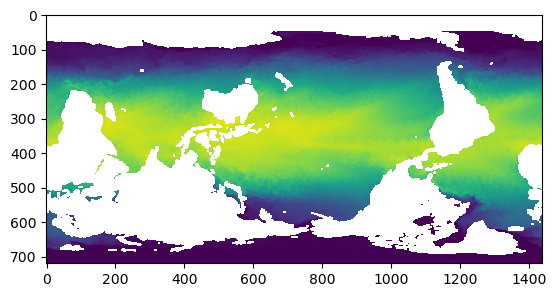

In [18]:
fig,ax=plt.subplots()
ax.imshow(sst[0])

What just happened?  This did not make a map?  It just took the sst array and plotted it.  Each array point has a latittude and longitude we could use to make a map.  But we didn't do that.  We just did a raw imshow which shows the array.  It is a nice start.   Read the help and see if you can flip the array? 

In [19]:
#?plt.imshow

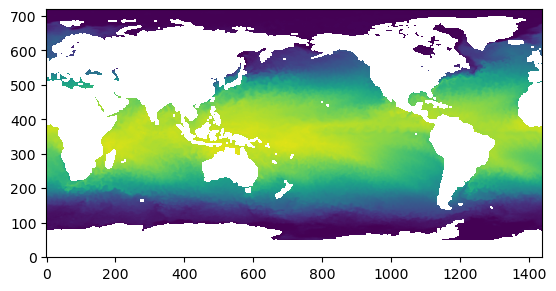

In [20]:
fig,ax=plt.subplots()
ax.imshow(sst[0],origin='lower')

imshow is nice as a quick way to show an array but it is not a map.  The next way to make a better map is pcolormesh.  It uses the lat and long so it is better but still not a map.  

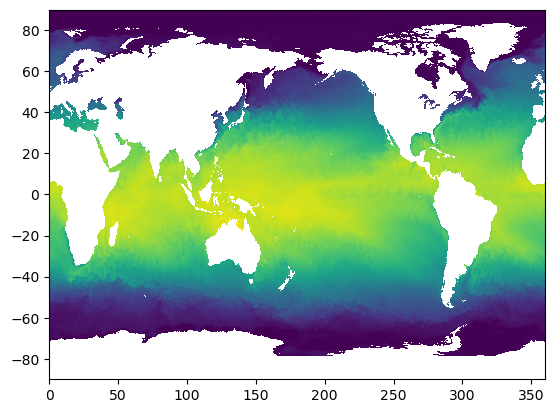

In [21]:
fig,ax=plt.subplots()
ax.pcolormesh(lon,lat,sst[0])

Lets try to make that nicer

* Let's go back and grab our last map and paste it in here.  You should be able to make it work

Text(0.5, 1.0, 'Temp\n(°C)')

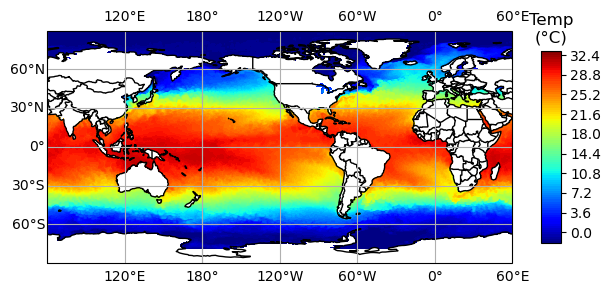

In [22]:
fig,ax=plt.subplots(subplot_kw={"projection":ccrs.PlateCarree(central_longitude=-120)})
fig.set_size_inches(7.5,5)

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(draw_labels=True)  #see if you like them.  

data, lonW = add_cyclic_point(sst[0], coord=lon)  

air_contour=ax.contourf(lonW, lat, data,
            transform=ccrs.PlateCarree(),
            cmap='jet',levels=100)

cbar_ax=fig.colorbar(air_contour,ax=ax,shrink=0.5, aspect=20*0.5) #shrink is the size and aspect keeps the width as 20 is the usual width
cbar_ax.ax.set_title('Temp\n(\N{DEGREE SIGN}C)')


### Let's make it look better
-  I am going to make the land a slightly different color
-  Then we need to set the levels better.  The reason is different days have different ranges.  
-  We will use linspace to get levels and then pass the levels.  You are setting the range.  For contourf you need to be over the min and max.  

Text(0.5, 1.0, 'Temp\n(°C)')

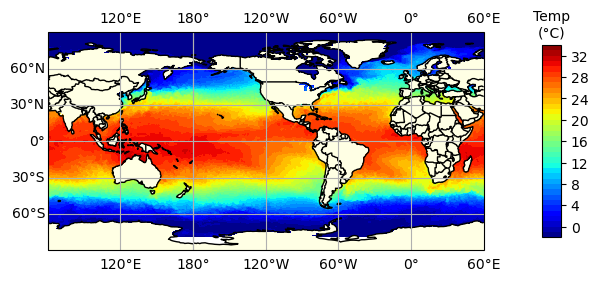

In [23]:
fig,ax=plt.subplots(subplot_kw={"projection":ccrs.PlateCarree(central_longitude=-120)})
fig.set_size_inches(7.5,5)

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS,edgecolor='k')
ax.add_feature(cartopy.feature.LAND,facecolor='xkcd:off white')
ax.gridlines(draw_labels=True)  #see if you like them.  

data, lonW = add_cyclic_point(sst[0], coord=lon)  

levels=np.linspace(-2,34,37)

air_contour=ax.contourf(lonW, lat, data,
            transform=ccrs.PlateCarree(),
            cmap='jet',levels=levels)

cbar_ax=fig.colorbar(air_contour,ax=ax,shrink=0.5, aspect=20*0.5,pad=0.1) #shrink is the size and aspect keeps the width as 20 is the usual width
cbar_ax.ax.set_title('Temp\n(\N{DEGREE SIGN}C)',fontsize=10)


### remember that we have 366 days of data.  
-  So lets set a parameter to day number that we can change
-  If you know me you should know a for loop is coming and we are stepping our way there.  
-  Now make a variable called "iday" and set it equal to the day you want to plot.  For example January 31 will be 30 because python starts at 0.  
-  Compare day 0 and day 180.  Do the temperatures look different?  

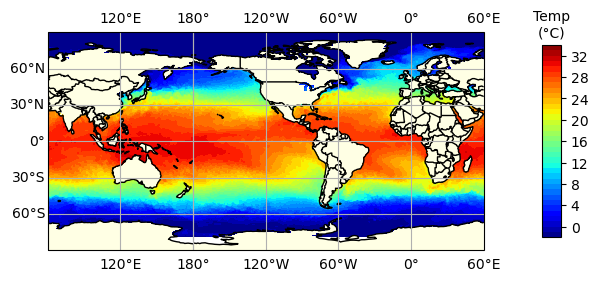

In [29]:
iday=1

fig,ax=plt.subplots(subplot_kw={"projection":ccrs.PlateCarree(central_longitude=-120)})
fig.set_size_inches(7.5,5)

ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS,edgecolor='k')
ax.add_feature(cartopy.feature.LAND,facecolor='xkcd:off white')
ax.gridlines(draw_labels=True)  #see if you like them.  

data, lonW = add_cyclic_point(sst[iday], coord=lon)  

levels=np.linspace(-2,34,37)

air_contour=ax.contourf(lonW, lat, data,
            transform=ccrs.PlateCarree(),
            cmap='jet',levels=levels)

cbar_ax=fig.colorbar(air_contour,ax=ax,shrink=0.5, aspect=20*0.5,pad=0.1) #shrink is the size and aspect keeps the width as 20 is the usual width
cbar_ax.ax.set_title('Temp\n(\N{DEGREE SIGN}C)',fontsize=10)


That is a good looking map!!!!

I am starting to see a path forward for how to make a movie of the temperatures over the year.  
-  Python is not perfect for making movies.  
-  We are going to make a modern flip book.  
-  We will save an image for each frame and then we can use python or a web program to put them together.  It is like making a burst on your phone into a movie.  
-  We want to end with an animated GIF with python or a program.  Things we will need to be able to do.

How do we do thi??
* Loop over all the data.
* Figure out the date for the data.
* plot the data.
* save the data in a unique file for each day
* use python/website to put it all togehter.  

So we need to learn each of these steps.  I will start with figuring out the date for each slice.  

### Back to our crazy dates!

In [26]:
print (f.variables['time'])

<class 'netCDF4._netCDF4.Variable'>
float64 time(time)
    long_name: Time
    units: days since 1800-01-01 00:00:00
    delta_t: 0000-00-01 00:00:00
    avg_period: 0000-00-01 00:00:00
    axis: T
    actual_range: [81814. 82179.]
unlimited dimensions: time
current shape = (366,)
filling on, default _FillValue of 9.969209968386869e+36 used


Still crazy!  
Time since 1800 in days!  Let's deal with it like last time.  Go cut and paste what we did. 

-  Set your startdate
-  calculate your datedelta
-  Add them together to figure out your date
-  use ndays again
-  Change ndays and see if it 


In [27]:
iday=180
startdate=datetime.datetime(1800,1,1)
datedelta=datetime.timedelta(days=time[iday])
mapdate=startdate+datedelta
print ("The date is {:%B %d, %Y}".format(mapdate))

The date is June 29, 2024


### We need a for loop
-  I do not know the best way to for loop here.
-  I see three options
-  just give us a number to loop 20.  e.g. 365.  But would get an error on a leap year.
-  We could do an enumerate loop.  
-  We could also just loop to length of a parameter.  
-  I am going to do np.arange(len(time))
-  then print iday
-  Important note.  I added [0:10] I did this to save paper and only print 10.  You can delete it.

In [39]:
for iday in np.arange(len(time))[0:10]:
    print(iday)  #uncomment.  Trying to save paper

0
1
2
3
4
5
6
7
8
9


Now print each day in the foor loop.  to save memory put the least amount of things needed in a for loop.  You can do this!

In [33]:
startdate=datetime.datetime(1800,1,1)

for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    print ("The date is {:%B %d, %Y}".format(mapdate)) 

The date is January 01, 2024
The date is January 02, 2024
The date is January 03, 2024
The date is January 04, 2024
The date is January 05, 2024
The date is January 06, 2024
The date is January 07, 2024
The date is January 08, 2024
The date is January 09, 2024
The date is January 10, 2024


Now make a loop where you give the count and the day.  So day 0 is January 1.

In [38]:
startdate=datetime.datetime(1800,1,1)
for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    print ("The date on day {} is {:%B %d, %Y}".format(iday,mapdate))

The date on day 0 is January 01, 2024
The date on day 1 is January 02, 2024
The date on day 2 is January 03, 2024
The date on day 3 is January 04, 2024
The date on day 4 is January 05, 2024
The date on day 5 is January 06, 2024
The date on day 6 is January 07, 2024
The date on day 7 is January 08, 2024
The date on day 8 is January 09, 2024
The date on day 9 is January 10, 2024


#### this might not make sense.  

If we are going to make 365 plots one for each day.  We need to save each to a file.  So we need to create a file name we can send to savfig.  You can't type 365 file names.  We need to automate!

-  We will want our files nicely oraganized.  
-  We could use the dates to name the files.  But we will lose their order.  You could name the file yyyymmdd and that should keep them in order.  I haven't tried yet.
-  Instead I will do a number in the file name.  
-  But we will want a three digit number in the name.  This will keep them all in order.  
-  it will look like 
    - sst_000.png
    - sst_001.png
    - sst_002.png
    - .... sst_364.png.  
-  We can use format to pad the numbers.  You remember this?  https://stackoverflow.com/questions/339007/nicest-way-to-pad-zeroes-to-string

In [41]:
startdate=datetime.datetime(1800,1,1)
for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    filename="sst_{:03d}.png".format(iday)
    print ("The date on day {} is {:%B %d, %Y} with filename {}".format(iday,mapdate,filename))

The date on day 0 is January 01, 2024 with filename sst_000.png
The date on day 1 is January 02, 2024 with filename sst_001.png
The date on day 2 is January 03, 2024 with filename sst_002.png
The date on day 3 is January 04, 2024 with filename sst_003.png
The date on day 4 is January 05, 2024 with filename sst_004.png
The date on day 5 is January 06, 2024 with filename sst_005.png
The date on day 6 is January 07, 2024 with filename sst_006.png
The date on day 7 is January 08, 2024 with filename sst_007.png
The date on day 8 is January 09, 2024 with filename sst_008.png
The date on day 9 is January 10, 2024 with filename sst_009.png


#### This confuses people!!!!!
- I will want to put the files into a subfolder.  
- 366 files in your main folder is a mess!
- So  make a folder named "sst" where you are working
- Now we can trick python with the file name
- we add the sst/ prefix to the name.
- the computer is tricked into putting the file into that folder
- I am ging to repeat this.  You named it sst/ but the folder doesn't exist until you make it and then it will put the files into it.

In [42]:
startdate=datetime.datetime(1800,1,1)
for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    filename="sst/sst_{:03d}.png".format(iday)
    print ("The date on day {} is {:%B %d, %Y} with filename {}".format(iday,mapdate,filename))

The date on day 0 is January 01, 2024 with filename sst/sst_000.png
The date on day 1 is January 02, 2024 with filename sst/sst_001.png
The date on day 2 is January 03, 2024 with filename sst/sst_002.png
The date on day 3 is January 04, 2024 with filename sst/sst_003.png
The date on day 4 is January 05, 2024 with filename sst/sst_004.png
The date on day 5 is January 06, 2024 with filename sst/sst_005.png
The date on day 6 is January 07, 2024 with filename sst/sst_006.png
The date on day 7 is January 08, 2024 with filename sst/sst_007.png
The date on day 8 is January 09, 2024 with filename sst/sst_008.png
The date on day 9 is January 10, 2024 with filename sst/sst_009.png


Now we know how to
* Make a title name with the date.
* make a file name
* loop over the array

But before you begin you need to think a little.  

### You need to think!!!!!!  Else your computer will crash

Each timestep we are going to make a figure, make a map, and save it.  

But making a figure and map are "expensive" and eat up cpu.  And you need to this 365 times.  

But unfortunately we can't use clear axis.  It doesn't work with cartopy.  So you need to open and CLOSE a figure during each step.  You need to close the figure each time.  Else your computer will crash.  you close the figure by doing plt.clost(fig)

So i would test things by running just a few days. use your [0:10]  Plus you can use kernal->interrupt to stop a run.

Don't forget a title with your name and date.  You need your name in the title.

Repeating.  you need a title with your name and date


TRICK:  you are making 365 files.  make them small.  use dpi=50.   So you call to savefig will look like fig.savefig(filename,dpi=50,bbox_inches='tight',facecolor='white')    You need to add the facecolor='white' to make the titles look good.

dpi=50 is probably too small.  If you have space on your computer I would use dpi=100.  The map comes out much nicer.  

The websites for making a gif are full or viruses.  I would use python.  

I found this stackoverflow example.  

https://stackoverflow.com/questions/41228209/making-gif-from-images-using-imageio-in-python

Look at the answers below and just update with your directories!

BUT THERE IS A BIG PROBLEM!  If you look up os.listdir It says the order of files is arbitrary.  On some computers is works and on some it doesn't and it jumbles the order.

We have two solutions.
1.  I did the solution of naming them nicely and reading in the nice names.  

1.  Kai came up with a great one about reading the files in (See below).  Kai googled this "python listdir in order".  It then restated that listserv jumbles the order.  But it says you can add the sorted function to the for loop.  See below!


PS.  This is slow.  My computer takes 30+ minutes and makes a lot of noise!

PPS.  You cannot open your movie in preview.  Use a web browser.

HW Final 10%
- Get rid of your weird days.
- You can delete and then use try/except
- You can delete and repeat the previous day with a new file name.  



The date on day 0 is January 01, 2024 with filename sst/sst_000.png
The date on day 1 is January 02, 2024 with filename sst/sst_001.png
The date on day 2 is January 03, 2024 with filename sst/sst_002.png
The date on day 3 is January 04, 2024 with filename sst/sst_003.png
The date on day 4 is January 05, 2024 with filename sst/sst_004.png
The date on day 5 is January 06, 2024 with filename sst/sst_005.png
The date on day 6 is January 07, 2024 with filename sst/sst_006.png
The date on day 7 is January 08, 2024 with filename sst/sst_007.png
The date on day 8 is January 09, 2024 with filename sst/sst_008.png
The date on day 9 is January 10, 2024 with filename sst/sst_009.png


## Make the GIF.  Choose a method.....

In [32]:
### option 1.  

images = []
for i in range(0,366):
    filename='sst/sst_{:03d}.png'.format(i)
    images.append(imageio.imread(filename))
#imageio.mimwrite('sst/omg_movie2.gif', images)    
#
imageio.mimsave('sst/omg_movie2.gif', images)
#imageio.mimsave('sst/omg_movie2.mp4', images)


In [ ]:
### option 2
png_dir = 'sst/'
images = []
for file_name in sorted(os.listdir(png_dir)):
    if file_name.endswith('.png'):
        file_path = os.path.join(png_dir, file_name)
        images.append(imageio.imread(file_path))
        
imageio.mimsave('sst/omg_movie2.gif', images)

# ANSWERS

In [34]:
startdate=datetime.datetime(1800,1,1)

for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    print ("The date is {:%B %d, %Y}".format(mapdate)) 

The date is January 01, 2024
The date is January 02, 2024
The date is January 03, 2024
The date is January 04, 2024
The date is January 05, 2024
The date is January 06, 2024
The date is January 07, 2024
The date is January 08, 2024
The date is January 09, 2024
The date is January 10, 2024


In [37]:
startdate=datetime.datetime(1800,1,1)
for iday in np.arange(len(time))[0:10]:
    datedelta=datetime.timedelta(days=time[iday])
    mapdate=startdate+datedelta
    print ("The date on day {} is {:%B %d, %Y}".format(iday,mapdate))

The date on day 0 is January 01, 2024
The date on day 1 is January 02, 2024
The date on day 2 is January 03, 2024
The date on day 3 is January 04, 2024
The date on day 4 is January 05, 2024
The date on day 5 is January 06, 2024
The date on day 6 is January 07, 2024
The date on day 7 is January 08, 2024
The date on day 8 is January 09, 2024
The date on day 9 is January 10, 2024


## Some extra stuff for me.

https://stackoverflow.com/questions/59014789/making-a-clean-high-quality-gif-with-fix-colorbar-for-multiple-xarray-plots

In [89]:
!pip install imageio-ffmpeg

     |████████████████████████████████| 22.5 MB 18.0 MB/s eta 0:00:01   |█████▌                          | 3.9 MB 6.5 MB/s eta 0:00:03     |████████████████▎               | 11.4 MB 6.5 MB/s eta 0:00:02     |█████████████████████▎          | 15.0 MB 6.5 MB/s eta 0:00:02     |██████████████████████████████▏ | 21.2 MB 18.0 MB/s eta 0:00:01


In [81]:
?imageio.mimsave

In [87]:
from PIL import Image  

In [ ]:
from PIL import Image  
img, *imgs = [Image.open(f) for f in fns_image]
img.save(fp=save_gif_dir+gif_name+'1.gif', format='GIF', append_images=imgs,
     save_all=True, duration=200, loop=0)